In [ ]:
import os, matplotlib, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
if not getattr(matplotlib, "_autosave_patched", False):
    _old_fig_savefig = matplotlib.figure.Figure.savefig
    def _savefig_prefix(self, fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_fig_savefig(self, fname, *args, **kwargs)
    matplotlib.figure.Figure.savefig = _savefig_prefix
    _old_plt_savefig = plt.savefig
    def _plt_savefig(fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_plt_savefig(fname, *args, **kwargs)
    plt.savefig = _plt_savefig
    matplotlib._autosave_patched = True


In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import vector

In [2]:
file = uproot.open("/ceph/omunkombwe/out_tracks60.root")
tree = file["events"]

In [3]:
DCHeDep = tree['DCH_DigiCollection.eDep'].arrays()
DCHPos_x = tree['DCH_DigiCollection.position.x'].arrays()
DCHPos_y = tree['DCH_DigiCollection.position.y'].arrays()
DCHPos_z = tree['DCH_DigiCollection.position.z'].arrays()
DCHquality = tree['DCH_DigiCollection.quality'].arrays()
DCHtime = tree['DCH_DigiCollection.time'].arrays()
DCHazimuthalAngle = tree['DCH_DigiCollection.wireAzimuthalAngle'].arrays()
DCHstereoAngle = tree['DCH_DigiCollection.wireStereoAngle'].arrays()
DCHcellID = tree['DCH_DigiCollection.cellID'].arrays()
DCHdistanceToWire = tree['DCH_DigiCollection.distanceToWire'].arrays()



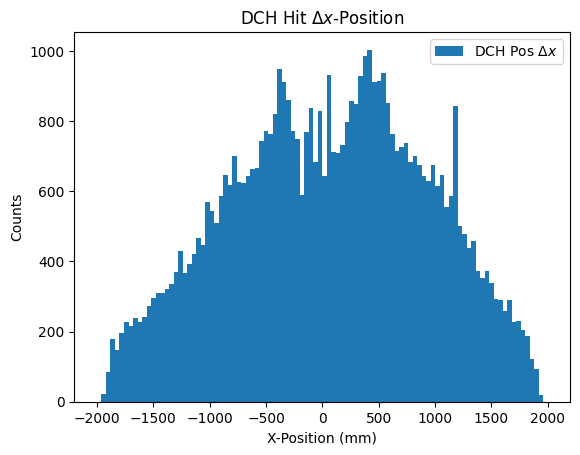

In [4]:
DCHPx = ak.flatten(ak.drop_none(DCHPos_x), axis=None)   # 1-D Awkward array
DCHPx = ak.to_numpy(DCHPx)                               # NumPy array

plt.hist(DCHPx, bins=100, range=(-2000, 2000), label='DCH Pos $\Delta x$')
plt.xlabel('X-Position (mm)')
plt.ylabel('Counts')
plt.title('DCH Hit $\Delta x$-Position')
plt.savefig('DCHPosX.png')  
plt.legend()
plt.show()

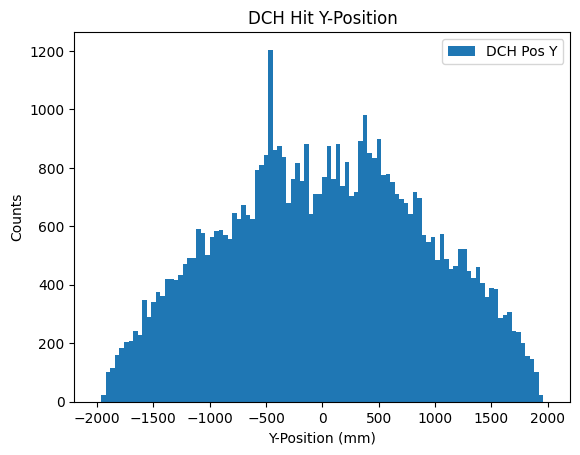

In [5]:
DCHPy = ak.flatten(ak.drop_none(DCHPos_y), axis=None)   # 1-D Awkward array
DCHPy = ak.to_numpy(DCHPy) 
plt.hist(DCHPy, bins=100, range=(-2000, 2000), label='DCH Pos Y')
plt.xlabel('Y-Position (mm)')
plt.ylabel('Counts')
plt.savefig('DCHPosY.png')
plt.legend()
plt.title('DCH Hit Y-Position')
plt.savefig('DCHPosY_Legend.png')
plt.show()   

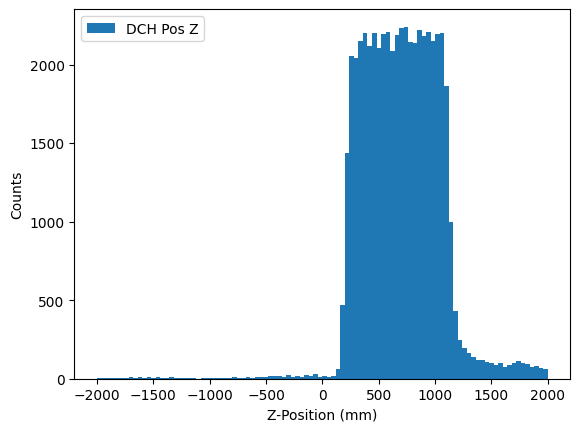

In [6]:
DCHPz = ak.flatten(ak.drop_none(DCHPos_z), axis=None)   # 1-D Awkward array
DCHPz = ak.to_numpy(DCHPz)
plt.hist(DCHPz, bins=100, range=(-2000, 2000), label='DCH Pos Z')
plt.xlabel('Z-Position (mm)')
plt.ylabel('Counts')
plt.savefig('DCHPosZ.png')
plt.legend()
plt.show()

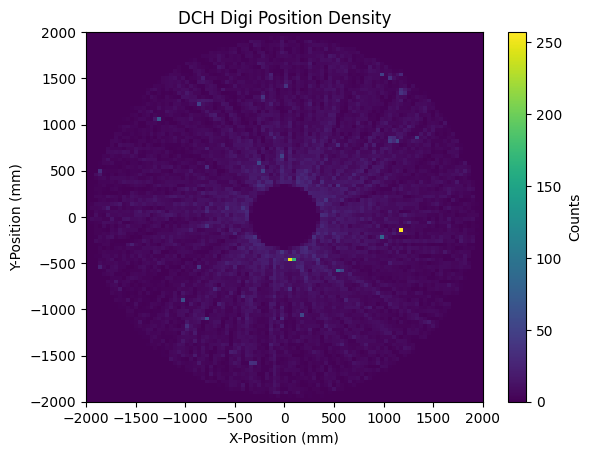

In [7]:
plt.hist2d(DCHPx, DCHPy, bins=100, range=[[-2000, 2000], [-2000, 2000]], cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X-Position (mm)')
plt.ylabel('Y-Position (mm)')
plt.title('DCH Digi Position Density')
plt.show()

In [ ]:
DCHPr = np.sqrt(DCHPx**2 + DCHPy**2 )
DCHPphi = np.arctan2(DCHPy, DCHPx)
DCHPz = DCHPz   

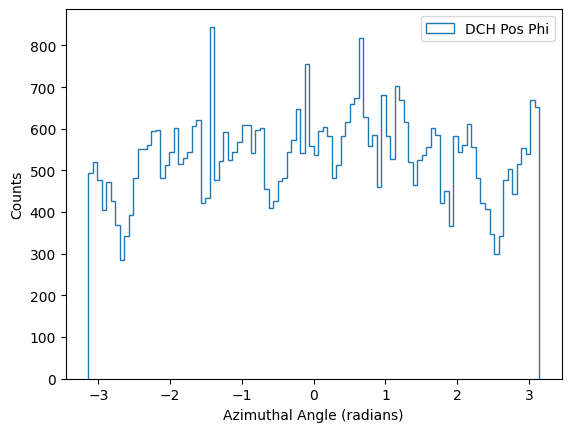

In [9]:
plt.hist(DCHPphi, bins=100, range=(-np.pi, np.pi), histtype='step', label='DCH Pos Phi')   
plt.xlabel('Azimuthal Angle (radians)')
plt.ylabel('Counts')
plt.legend()
plt.show()  

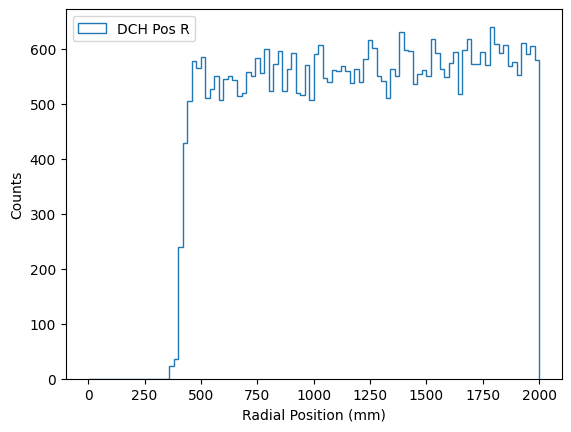

In [10]:
plt.hist(DCHPr, bins=100, range=(0, 2000), histtype='step', label='DCH Pos R')
plt.xlabel('Radial Position (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [11]:
mcp_pdg = tree['MCParticles.PDG'].arrays()
mcp_px = tree['MCParticles.momentum.x'].arrays()
mcp_py = tree['MCParticles.momentum.y'].arrays()
mcp_pz = tree['MCParticles.momentum.z'].arrays()
mcp_vx = tree['MCParticles.vertex.x'].arrays()
mcp_vy = tree['MCParticles.vertex.y'].arrays()
mcp_vz = tree['MCParticles.vertex.z'].arrays()
mcp_vendx = tree['MCParticles.endpoint.x'].arrays()
mcp_vendy = tree['MCParticles.endpoint.y'].arrays()
mcp_vendz = tree['MCParticles.endpoint.z'].arrays()
mcp_mendx = tree['MCParticles.momentumAtEndpoint.x'].arrays()
mcp_mendy = tree['MCParticles.momentumAtEndpoint.y'].arrays()
mcp_mendz = tree['MCParticles.momentumAtEndpoint.z'].arrays()
mcp_gen = tree['MCParticles.generatorStatus'].arrays()
mcp_m = tree['MCParticles.mass'].arrays()
mcp_q = tree['MCParticles.charge'].arrays()
mcp_t = tree['MCParticles.time'].arrays()

In [12]:
px_np = ak.flatten(ak.drop_none(mcp_px), axis=None)
px_np = ak.to_numpy(px_np)
py_np = ak.flatten(ak.drop_none(mcp_py), axis=None)
py_np = ak.to_numpy(py_np)
pz_np = ak.flatten(ak.drop_none(mcp_pz), axis=None)
pz_np = ak.to_numpy(pz_np)  

In [13]:
pT = np.sqrt(px_np**2 + py_np**2)
p = np.sqrt(px_np**2 + py_np**2 + pz_np**2)
eta = 0.5 * np.log((p + pz_np) / (p - pz_np))
phi = np.arctan2(py_np, px_np)

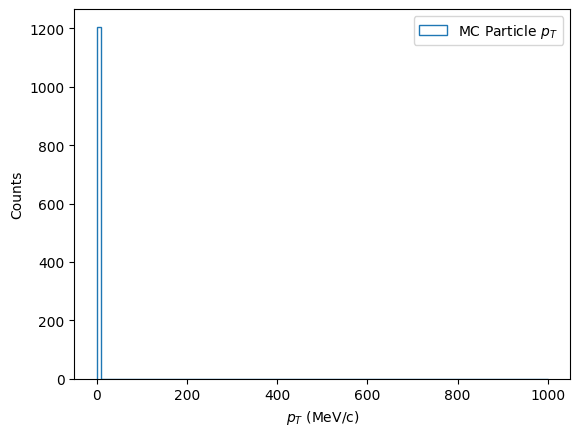

In [14]:
plt.hist(pT, bins=100, range=(0, 1000), histtype='step', label='MC Particle $p_T$')
plt.xlabel('$p_T$ (MeV/c)')
plt.ylabel('Counts')
plt.legend()
plt.show()

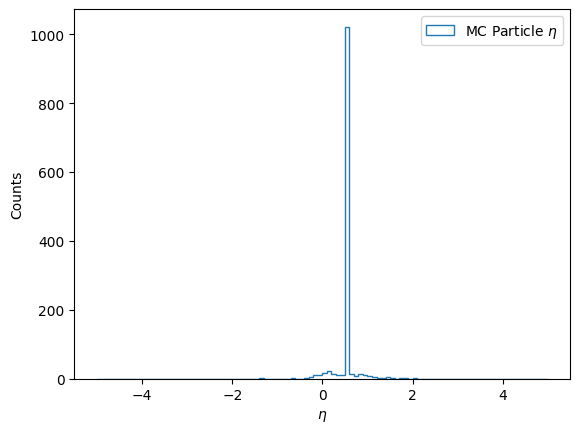

In [15]:
plt.hist(eta, bins=100, range=(-5, 5), histtype='step', label='MC Particle $\eta$')
plt.xlabel('$\eta$')
plt.ylabel('Counts') 
plt.legend()
plt.show()       

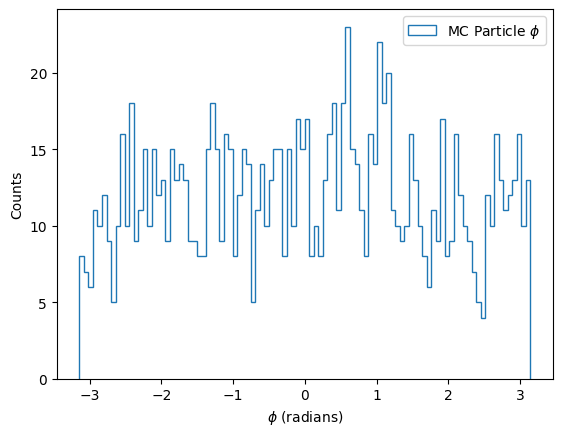

In [16]:
plt.hist(phi, bins=100, range=(-np.pi, np.pi), histtype='step', label='MC Particle $\phi$')
plt.xlabel('$\phi$ (radians)')
plt.ylabel('Counts')
plt.legend()
plt.show()

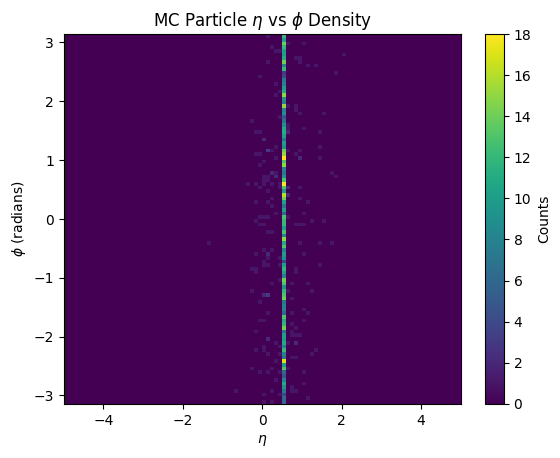

In [17]:
plt.hist2d(eta, phi, bins=100, range=[[-5, 5], [-np.pi, np.pi]], cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('$\eta$')
plt.ylabel('$\phi$ (radians)')
plt.title('MC Particle $\eta$ vs $\phi$ Density')
plt.show()

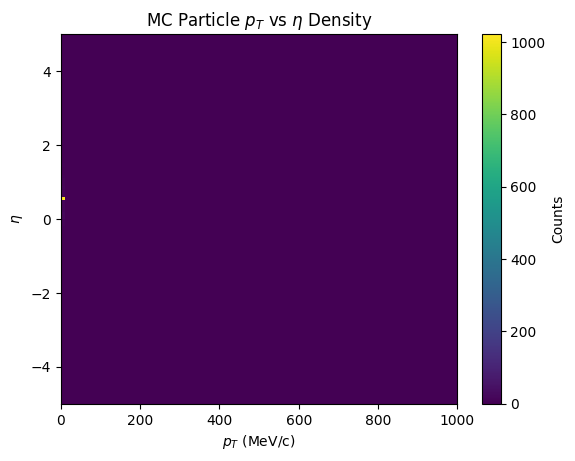

In [18]:
plt.hist2d(pT, eta, bins=100, range=[[0, 1000], [-5, 5]], cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('$p_T$ (MeV/c)')
plt.ylabel('$\eta$')
plt.title('MC Particle $p_T$ vs $\eta$ Density')
plt.show()

In [19]:
vx_np = ak.flatten(ak.drop_none(mcp_vx), axis=None)
vx_np = ak.to_numpy(vx_np)
vy_np = ak.flatten(ak.drop_none(mcp_vy), axis=None)
vy_np = ak.to_numpy(vy_np)
vz_np = ak.flatten(ak.drop_none(mcp_vz), axis=None)
vz_np = ak.to_numpy(vz_np)

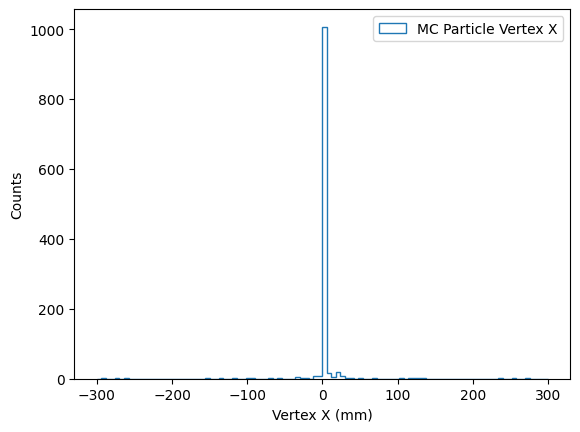

In [20]:
plt.hist(vx_np, bins=100, range=(-300, 300), histtype='step', label='MC Particle Vertex X')
plt.xlabel('Vertex X (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

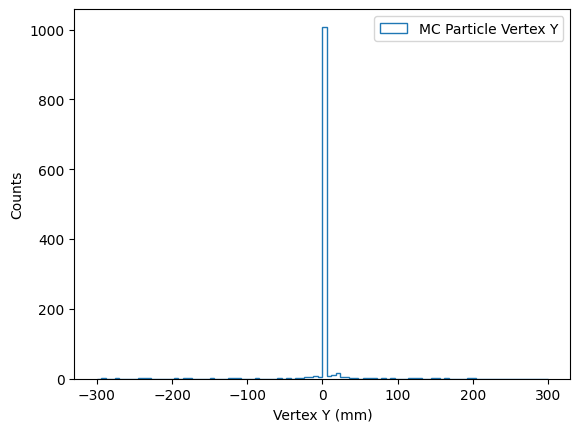

In [21]:
plt.hist(vy_np, bins=100, range=(-300, 300), histtype='step', label='MC Particle Vertex Y')
plt.xlabel('Vertex Y (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

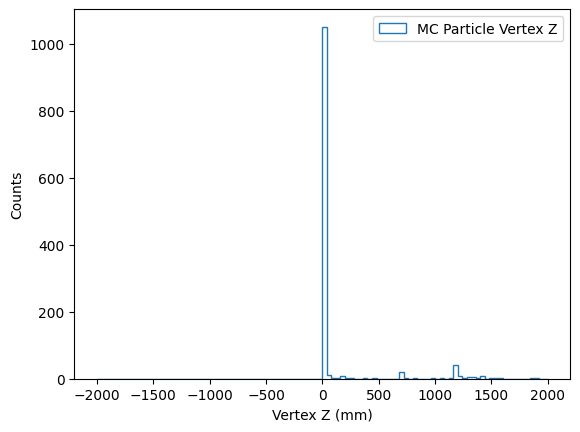

In [22]:
plt.hist(vz_np, bins=100, range=(-2000, 2000), histtype='step', label='MC Particle Vertex Z')
plt.xlabel('Vertex Z (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

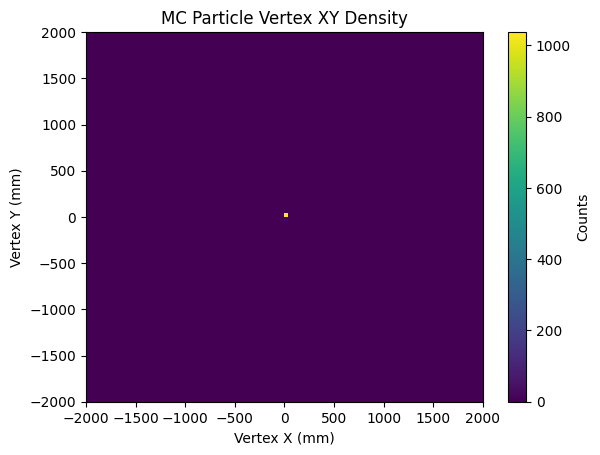

In [23]:
plt.hist2d(vx_np, vy_np, bins=100, range=[[-2000, 2000], [-2000, 2000]], cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Vertex X (mm)')
plt.ylabel('Vertex Y (mm)')
plt.title('MC Particle Vertex XY Density')
plt.show()

In [24]:
v_r = np.sqrt(vx_np**2 + vy_np**2)
v_phi = np.arctan2(vy_np, vx_np)
v_z = vz_np

In [25]:
vendx_np = ak.flatten(ak.drop_none(mcp_vendx), axis=None)
vendx_np = ak.to_numpy(vendx_np)
vendy_np = ak.flatten(ak.drop_none(mcp_vendy), axis=None)
vendy_np = ak.to_numpy(vendy_np)
vendz_np = ak.flatten(ak.drop_none(mcp_vendz), axis=None)
vendz_np = ak.to_numpy(vendz_np)

In [26]:
r_end = np.sqrt(vendx_np**2 + vendy_np**2)
phi_end = np.arctan2(vendy_np, vendx_np)
z_end = vendz_np

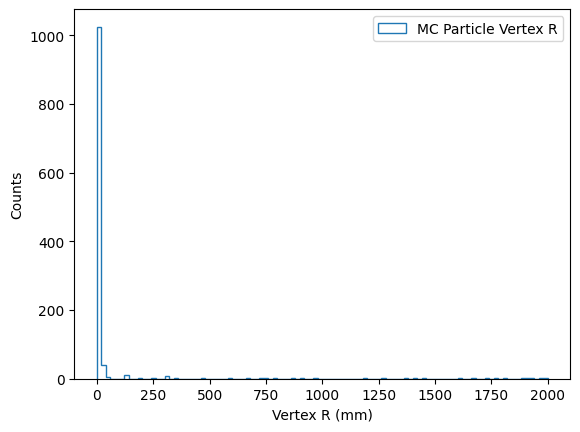

In [27]:
plt.hist(v_r, bins=100, range=(0, 2000), histtype='step', label='MC Particle Vertex R')
plt.xlabel('Vertex R (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

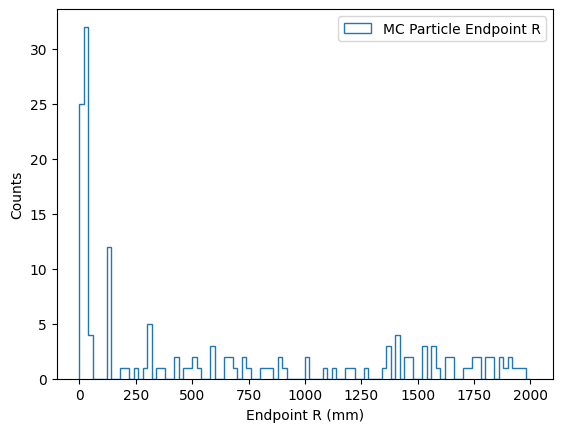

In [28]:
plt.hist(r_end, bins=100, range=(0, 2000), histtype='step', label='MC Particle Endpoint R') 
plt.xlabel('Endpoint R (mm)')
plt.ylabel('Counts')
plt.legend()
plt.show()

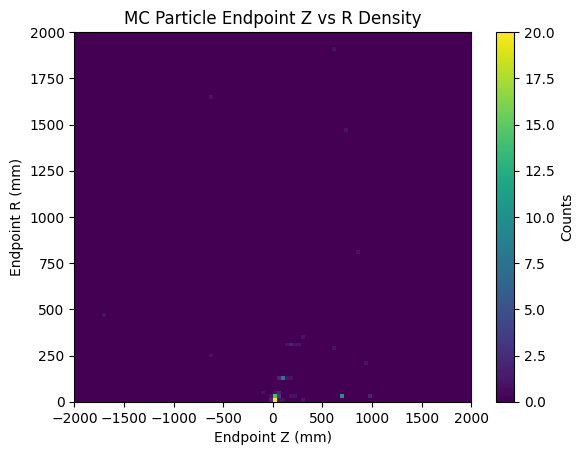

In [29]:
plt.hist2d(z_end, r_end, bins=100, range=[[-2000, 2000], [0, 2000]], cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Endpoint Z (mm)')
plt.ylabel('Endpoint R (mm)')
plt.title('MC Particle Endpoint Z vs R Density')
plt.show()

In [30]:
Lxyz = abs(r_end - v_r)

In [31]:
Lxy = np.sqrt((vendx_np - vx_np)**2 + (vendy_np - vy_np)**2)

In [ ]:
import os, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
nb = "TrackFinderInputDigis"
nums = plt.get_fignums()
for i, num in enumerate(nums, 1):
    fig = plt.figure(num)
    fname = f"{nb}_fig{i}.png"
    fig.savefig(fname, dpi=150)
print(f"Saved {len(nums)} figure(s) to {OUT_DIR}")
